In [1]:
!pip install catboost
!pip install xgboost

In [2]:
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import fbeta_score, make_scorer, confusion_matrix, recall_score, precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET_COL = "target_patology"
BETA = 2
THRESHOLD_GRID = np.arange(0.05, 1.00, 0.05)

## Загрузка данных и описание колонок

In [3]:
df = pd.read_csv("2025_11_26_eda_final_ecg_data.csv", low_memory=False)
print("shape:", df.shape)
df.head(3)

shape: (9793, 42)


,heart_axis_norm,V1_pathological_Q,age,I_prop_censored,II_wavelet_entropy,II_SNR_dB,III_PSD_std_freq,III_wavelet_E2,AVR_RMSSD,AVR_STFT_energy,AVR_SNR_dB,AVR_prop_censored,AVL_STFT_energy,AVL_SNR_dB,AVF_SNR_dB,V1_RMSSD,V1_STFT_energy,V1_wavelet_entropy,V1_SNR_dB,V2_STFT_energy,V2_SNR_dB,V2_Q_wave_amp,V3_STFT_energy,V3_SNR_dB,V3_Q_wave_amp,V4_STFT_energy,V4_SNR_dB,V5_SNR_dB,V5_prop_censored,V5_Q_wave_amp,V6_STFT_energy,V6_SNR_dB,V6_prop_censored,meanRR_global,V3_PSD_mean_freq,V5_PSD_std_freq,AVF_wavelet_E5,I_wavelet_E5,I_wavelet_entropy,target_norm,target_arrhythmia,target_infarction
0,1,0,56.0,0.007,5.419053,24.614638,10.744334,0.199637,55.565277,0.000049,11.494849,0.005,0.000036,5.219391,8.615288,24.748737,0.000071,5.395219,34.069058,0.000250,29.086629,0.061861,0.000076,27.857958,0.054091,0.000050,25.957710,37.043980,0.011,0.059730,0.000063,41.418078,0.001,932.814815,12.222654,6.369762,0.076317,0.673067,5.789799,1,0,0
1,1,0,19.0,0.011,4.863514,11.281906,6.079428,1.519053,353.647659,0.000205,13.448662,0.004,0.000072,11.842842,10.300809,62.289646,0.000362,5.637168,13.634131,0.001357,30.604034,0.072253,0.000926,26.778794,0.097217,0.000516,36.819489,30.670310,0.012,0.102146,0.000225,22.411185,0.012,1235.629960,5.687558,9.253184,1.437292,0.888177,5.132125,1,0,0
2,1,0,37.0,0.013,4.893569,25.876320,6.719915,0.305148,72.543091,0.000079,23.365255,0.008,0.000059,20.288585,25.306726,26.457513,0.000074,5.683308,32.862776,0.000120,42.750413,0.067168,0.000153,20.615563,0.095022,0.000107,31.332773,18.945366,0.012,0.065056,0.000061,18.912740,0.011,940.277778,12.888998,8.601877,0.098511,1.169473,5.820171,1,0,0


In [4]:
categorical_columns = ["heart_axis_norm", "V1_pathological_Q"]

numeric_columns = [
    "age", "I_prop_censored", "II_wavelet_entropy", "II_SNR_dB", "III_PSD_std_freq",
    "III_wavelet_E2", "AVR_RMSSD", "AVR_STFT_energy", "AVR_SNR_dB", "AVR_prop_censored",
    "AVL_STFT_energy", "AVL_SNR_dB", "AVF_SNR_dB", "V1_RMSSD", "V1_STFT_energy",
    "V1_wavelet_entropy", "V1_SNR_dB", "V2_STFT_energy", "V2_SNR_dB", "V2_Q_wave_amp",
    "V3_STFT_energy", "V3_SNR_dB", "V3_Q_wave_amp", "V4_STFT_energy", "V4_SNR_dB",
    "V5_SNR_dB", "V5_prop_censored", "V5_Q_wave_amp", "V6_STFT_energy", "V6_SNR_dB",
    "V6_prop_censored", "meanRR_global", "V3_PSD_mean_freq", "V5_PSD_std_freq",
    "AVF_wavelet_E5", "I_wavelet_E5", "I_wavelet_entropy",
]

df["target_patology"] = 1 - df["target_norm"]

target_columns = ["target_patology", "target_norm", "target_arrhythmia", "target_infarction"]

print("Положительный класс TARGET_COL:")
print(df[TARGET_COL].value_counts())
print("Доля positive:", round(df[TARGET_COL].mean(), 4))

Положительный класс TARGET_COL:
target_patology
1    5404
0    4389
Name: count, dtype: int64
Доля positive: 0.5518


## Разбиение train / val / test

In [5]:
X = df[categorical_columns + numeric_columns].copy()
y = df[TARGET_COL].copy()

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {len(X_train)} ({100 * len(X_train) / len(X):.1f}%)")
print(f"Val:   {len(X_val)} ({100 * len(X_val) / len(X):.1f}%)")
print(f"Test:  {len(X_test)} ({100 * len(X_test) / len(X):.1f}%)")

print("\nДоля positive:")
print("train:", round(y_train.mean(), 4))
print("val:  ", round(y_val.mean(), 4))
print("test: ", round(y_test.mean(), 4))

Train: 6267 (64.0%)
Val:   1567 (16.0%)
Test:  1959 (20.0%)

Доля positive:
train: 0.5518
val:   0.552
test:  0.5518


## Feature engineering

Свои признаки:
- средние и стандартные отклонения по нескольким группам ECG-признаков;
- отношение сигнала к RR-интервалу;
- взаимодействие возраста и RR;
- средний уровень Q-wave;
- кластерный признак `ecg_cluster`, полученный через `KMeans` на train без утечки.

In [6]:
snr_cols = ["II_SNR_dB", "AVR_SNR_dB", "AVL_SNR_dB", "AVF_SNR_dB", "V1_SNR_dB", "V2_SNR_dB", "V3_SNR_dB", "V4_SNR_dB", "V5_SNR_dB", "V6_SNR_dB"]
stft_cols = ["AVR_STFT_energy", "AVL_STFT_energy", "V1_STFT_energy", "V2_STFT_energy", "V3_STFT_energy", "V4_STFT_energy", "V6_STFT_energy"]
q_cols = ["V2_Q_wave_amp", "V3_Q_wave_amp", "V5_Q_wave_amp"]
entropy_cols = ["II_wavelet_entropy", "V1_wavelet_entropy", "I_wavelet_entropy"]
prop_cols = ["I_prop_censored", "AVR_prop_censored", "V5_prop_censored", "V6_prop_censored"]
wavelet_cols = ["III_wavelet_E2", "AVF_wavelet_E5", "I_wavelet_E5"]

def add_engineered_features(df_part: pd.DataFrame) -> pd.DataFrame:
    part = df_part.copy()

    part["snr_mean"] = part[snr_cols].mean(axis=1)
    part["snr_std"] = part[snr_cols].std(axis=1)
    part["stft_mean"] = part[stft_cols].mean(axis=1)
    part["q_amp_mean"] = part[q_cols].mean(axis=1)
    part["entropy_mean"] = part[entropy_cols].mean(axis=1)
    part["prop_censored_sum"] = part[prop_cols].sum(axis=1)
    part["wavelet_mean"] = part[wavelet_cols].mean(axis=1)

    part["snr_rr_ratio"] = part["snr_mean"] / (part["meanRR_global"] + 1e-6)
    part["age_rr_interaction"] = part["age"] * part["meanRR_global"]
    part["path_q_strength"] = part["V1_pathological_Q"] * part["q_amp_mean"]
    part["heart_axis_age"] = part["heart_axis_norm"] * part["age"]
    part["stft_to_snr_ratio"] = part["stft_mean"] / (part["snr_mean"].abs() + 1e-6)

    return part

In [7]:
class ThresholdModel:
    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold

    def predict(self, X):
        proba = self.model.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

    def __getattr__(self, name):
        return getattr(self.model, name)


def build_feature_pack(X_train_df, X_val_df, X_test_df, mode="base", n_clusters=5):
    train_df = X_train_df.copy()
    val_df = X_val_df.copy()
    test_df = X_test_df.copy()

    num_cols = numeric_columns.copy()
    cat_cols = categorical_columns.copy()

    kmeans_scaler = None
    kmeans_model = None

    if mode == "engineered":
        train_df = add_engineered_features(train_df)
        val_df = add_engineered_features(val_df)
        test_df = add_engineered_features(test_df)

        new_num_cols = [
            "snr_mean", "snr_std", "stft_mean", "q_amp_mean", "entropy_mean",
            "prop_censored_sum", "wavelet_mean", "snr_rr_ratio",
            "age_rr_interaction", "path_q_strength", "heart_axis_age",
            "stft_to_snr_ratio",
        ]
        num_cols = num_cols + new_num_cols

        kmeans_scaler = StandardScaler()
        train_for_cluster = kmeans_scaler.fit_transform(train_df[num_cols])
        val_for_cluster = kmeans_scaler.transform(val_df[num_cols])
        test_for_cluster = kmeans_scaler.transform(test_df[num_cols])

        kmeans_model = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
        train_df["ecg_cluster"] = kmeans_model.fit_predict(train_for_cluster)
        val_df["ecg_cluster"] = kmeans_model.predict(val_for_cluster)
        test_df["ecg_cluster"] = kmeans_model.predict(test_for_cluster)
        cat_cols = cat_cols + ["ecg_cluster"]

    for part in [train_df, val_df, test_df]:
        part.replace([np.inf, -np.inf], np.nan, inplace=True)

    train_medians = train_df[num_cols].median()

    for part in [train_df, val_df, test_df]:
        part[num_cols] = part[num_cols].fillna(train_medians)
        for c in cat_cols:
            part[c] = part[c].fillna(0)

    final_scaler = StandardScaler()
    X_train_scaled = np.hstack([final_scaler.fit_transform(train_df[num_cols]), train_df[cat_cols].to_numpy()])
    X_val_scaled = np.hstack([final_scaler.transform(val_df[num_cols]), val_df[cat_cols].to_numpy()])
    X_test_scaled = np.hstack([final_scaler.transform(test_df[num_cols]), test_df[cat_cols].to_numpy()])

    feature_names = num_cols + cat_cols

    return {
        "mode": mode,
        "X_train": X_train_scaled,
        "X_val": X_val_scaled,
        "X_test": X_test_scaled,
        "numeric_cols": num_cols,
        "categorical_cols": cat_cols,
        "feature_names": feature_names,
        "final_scaler": final_scaler,
        "train_medians": train_medians,
        "kmeans_scaler": kmeans_scaler,
        "kmeans_model": kmeans_model,
        "n_features": len(feature_names),
    }


def threshold_table(model, Xv, yv, beta=BETA):
    proba = model.predict_proba(Xv)[:, 1]
    rows = []
    for t in THRESHOLD_GRID:
        pred = (proba >= t).astype(int)
        prec = precision_score(yv, pred, zero_division=0)
        rec = recall_score(yv, pred, zero_division=0)
        f2 = fbeta_score(yv, pred, beta=beta, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(yv, pred).ravel()
        rows.append({
            "threshold": round(float(t), 2),
            "precision": prec,
            "recall": rec,
            "f2": f2,
            "fp": fp,
            "tp": tp,
            "fn": fn,
            "tn": tn,
        })
    thr_df = pd.DataFrame(rows)
    best_thr = float(thr_df.loc[thr_df["f2"].idxmax(), "threshold"])
    return thr_df, best_thr


def plot_threshold_analysis(thr_df, title_suffix=""):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    axes[0, 0].plot(thr_df["threshold"], thr_df["precision"], "bo-", label="Precision")
    axes[0, 0].plot(thr_df["threshold"], thr_df["recall"], "ro-", label="Recall")
    axes[0, 0].set_title(f"Precision / Recall {title_suffix}")
    axes[0, 0].grid(True)
    axes[0, 0].legend()

    axes[0, 1].plot(thr_df["recall"], thr_df["precision"], "go-")
    axes[0, 1].set_title(f"PR-поведение {title_suffix}")
    axes[0, 1].grid(True)

    axes[1, 0].plot(thr_df["threshold"], thr_df["fn"], "ro-", label="FN")
    axes[1, 0].plot(thr_df["threshold"], thr_df["fp"], "bo-", label="FP")
    axes[1, 0].set_title(f"Ошибки vs threshold {title_suffix}")
    axes[1, 0].grid(True)
    axes[1, 0].legend()

    axes[1, 1].plot(thr_df["threshold"], thr_df["f2"], "mo-", label="F2")
    axes[1, 1].set_title(f"F2 vs threshold {title_suffix}")
    axes[1, 1].grid(True)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

In [8]:
feature_packs = {
    "base": build_feature_pack(X_train, X_val, X_test, mode="base"),
    "engineered": build_feature_pack(X_train, X_val, X_test, mode="engineered", n_clusters=5),
}

for name, pack in feature_packs.items():
    print(name, "->", pack["n_features"], "features")

base -> 39 features
engineered -> 52 features


## Настройка метрики и функция запуска эксперимента

In [9]:
f2_scorer = make_scorer(fbeta_score, beta=BETA, pos_label=1)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

results_rows = []
fitted_models = {}

def run_experiment(experiment_name, model_label, feature_set_name, estimator, param_grid, show_threshold_plot=False):
    pack = feature_packs[feature_set_name]
    start = time.perf_counter()

    gs = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=f2_scorer,
        cv=cv,
        n_jobs=-1,
        verbose=1,
    )
    gs.fit(pack["X_train"], y_train)

    fit_time_sec = time.perf_counter() - start

    best_model = gs.best_estimator_
    thr_df, thr = threshold_table(best_model, pack["X_val"], y_val, beta=BETA)

    if show_threshold_plot:
        plot_threshold_analysis(thr_df, title_suffix=f"({experiment_name})")

    wrapped = ThresholdModel(best_model, threshold=thr)

    y_val_pred = wrapped.predict(pack["X_val"])
    y_test_pred = wrapped.predict(pack["X_test"])

    val_f2 = fbeta_score(y_val, y_val_pred, beta=BETA, zero_division=0)
    test_f2 = fbeta_score(y_test, y_test_pred, beta=BETA, zero_division=0)
    val_recall = recall_score(y_val, y_val_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)

    row = {
        "experiment": experiment_name,
        "model": model_label,
        "feature_set": feature_set_name,
        "n_features": pack["n_features"],
        "cv_f2": round(float(gs.best_score_), 4),
        "val_f2": round(float(val_f2), 4),
        "test_f2": round(float(test_f2), 4),
        "val_recall": round(float(val_recall), 4),
        "test_recall": round(float(test_recall), 4),
        "threshold": thr,
        "fit_time_sec": round(float(fit_time_sec), 2),
        "best_params": json.dumps(gs.best_params_, ensure_ascii=False),
    }
    results_rows.append(row)

    fitted_models[experiment_name] = {
        "grid_search": gs,
        "raw_estimator": best_model,
        "threshold_model": wrapped,
        "threshold_table": thr_df,
        "best_threshold": thr,
        "feature_pack": pack,
    }

    print(f"\n=== {experiment_name} ===")
    print("best params:", gs.best_params_)
    print("best cv_f2:", round(gs.best_score_, 4))
    print("best threshold:", thr)
    print("val_f2:", round(val_f2, 4), "| test_f2:", round(test_f2, 4))
    print("val_recall:", round(val_recall, 4), "| test_recall:", round(test_recall, 4))
    print("fit_time_sec:", round(fit_time_sec, 2))

## Обучаем разные модели

Что тут есть:
1. baseline на логистической регрессии
2. дерево
3. лес
4. два бустинга
5. сравнение `base` и `engineered` для леса и бустингов

Fitting 3 folds for each of 6 candidates, totalling 18 fits


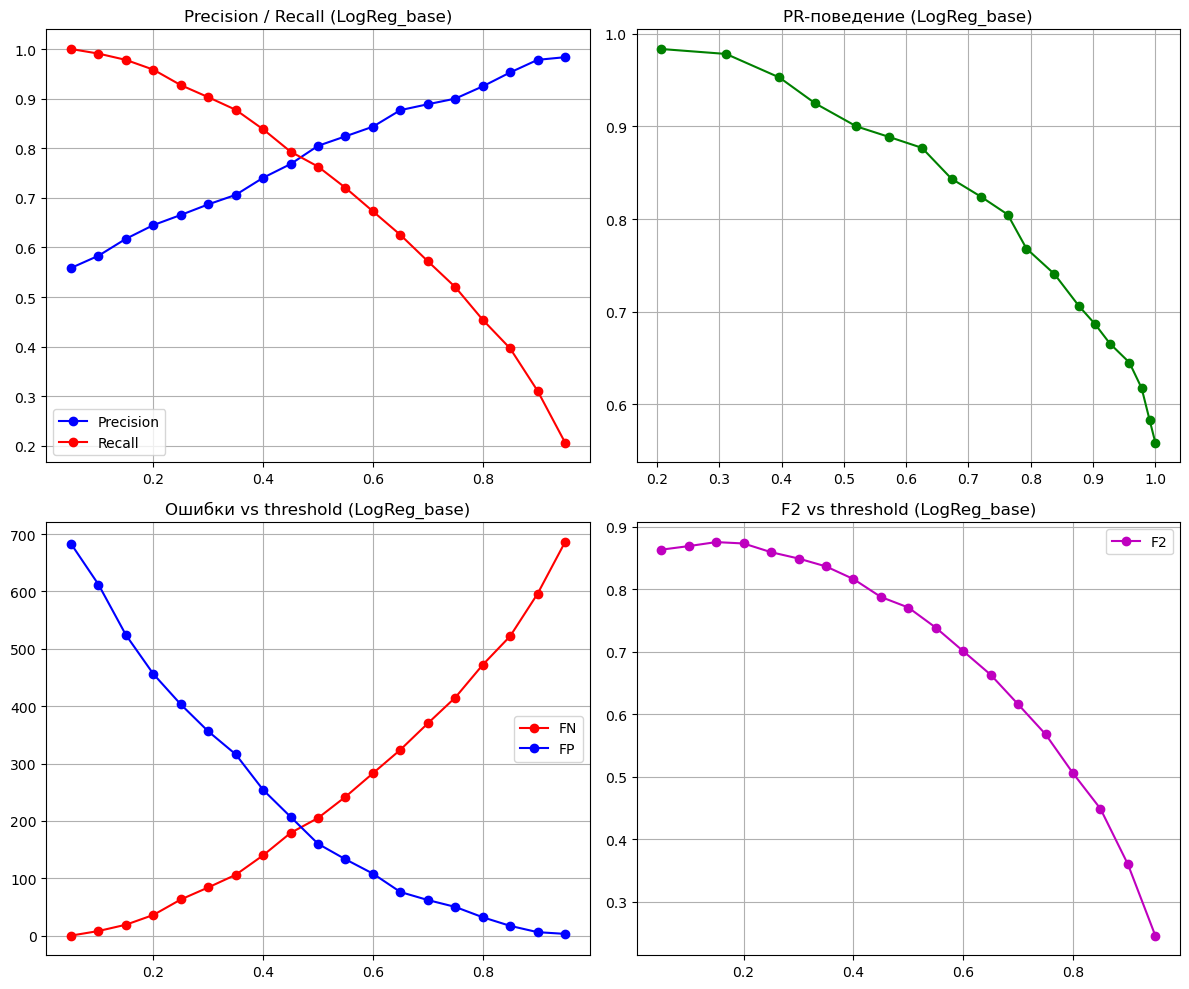


=== LogReg_base ===
best params: {'C': 1.0, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
best cv_f2: 0.7839
best threshold: 0.15
val_f2: 0.8758 | test_f2: 0.8688
val_recall: 0.978 | test_recall: 0.9732
fit_time_sec: 5.66


In [10]:
# Логистическая регрессия — baseline на base features
run_experiment(
    experiment_name="LogReg_base",
    model_label="LogisticRegression",
    feature_set_name="base",
    estimator=LogisticRegression(random_state=RANDOM_STATE, max_iter=3000),
    param_grid={
        "C": [0.1, 1.0, 3.0],
        "solver": ["lbfgs"],
        "penalty": ["l2"],
        "class_weight": [None, "balanced"],
    },
    show_threshold_plot=True,
)

In [11]:
# Дерево — base
run_experiment(
    experiment_name="DecisionTree_base",
    model_label="DecisionTree",
    feature_set_name="base",
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid={
        "max_depth": [4, 6, 8, None],
        "min_samples_split": [2, 20, 80],
        "min_samples_leaf": [1, 10, 30],
        "ccp_alpha": [0.0, 0.001, 0.01],
        "class_weight": [None, "balanced"],
    },
)

Fitting 3 folds for each of 216 candidates, totalling 648 fits

=== DecisionTree_base ===
best params: {'ccp_alpha': 0.001, 'class_weight': None, 'max_depth': None, 'min_samples_leaf': 30, 'min_samples_split': 80}
best cv_f2: 0.7609
best threshold: 0.1
val_f2: 0.8729 | test_f2: 0.8638
val_recall: 0.9769 | test_recall: 0.9695
fit_time_sec: 5.22


In [12]:
# Случайный лес — base
run_experiment(
    experiment_name="RandomForest_base",
    model_label="RandomForest",
    feature_set_name="base",
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid={
        "n_estimators": [200],
        "max_depth": [12, None],
        "min_samples_split": [2, 20],
        "min_samples_leaf": [1, 10, 30],
        "max_features": ["sqrt", 0.6],
        "class_weight": [None, "balanced"],
    },
)

Fitting 3 folds for each of 48 candidates, totalling 144 fits

=== RandomForest_base ===
best params: {'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 20, 'n_estimators': 200}
best cv_f2: 0.8324
best threshold: 0.3
val_f2: 0.8861 | test_f2: 0.874
val_recall: 0.9584 | test_recall: 0.9482
fit_time_sec: 55.73


In [13]:
# Случайный лес — engineered
run_experiment(
    experiment_name="RandomForest_engineered",
    model_label="RandomForest",
    feature_set_name="engineered",
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid={
        "n_estimators": [200],
        "max_depth": [12, None],
        "min_samples_split": [2, 20],
        "min_samples_leaf": [1, 10, 30],
        "max_features": ["sqrt", 0.6],
        "class_weight": [None, "balanced"],
    },
)

Fitting 3 folds for each of 48 candidates, totalling 144 fits

=== RandomForest_engineered ===
best params: {'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 20, 'n_estimators': 200}
best cv_f2: 0.8304
best threshold: 0.2
val_f2: 0.8859 | test_f2: 0.8772
val_recall: 0.9873 | test_recall: 0.9806
fit_time_sec: 69.58


In [14]:
# XGBoost — base
run_experiment(
    experiment_name="XGBoost_base",
    model_label="XGBoost",
    feature_set_name="base",
    estimator=XGBClassifier(
        random_state=RANDOM_STATE,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
    ),
    param_grid={
        "n_estimators": [200, 400],
        "max_depth": [3, 5],
        "learning_rate": [0.03, 0.07],
        "subsample": [0.8],
        "colsample_bytree": [0.8],
        "reg_lambda": [1, 5],
        "min_child_weight": [1, 5],
        "scale_pos_weight": [1.0, 1.25],
    },
)

Fitting 3 folds for each of 64 candidates, totalling 192 fits

=== XGBoost_base ===
best params: {'colsample_bytree': 0.8, 'learning_rate': 0.07, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200, 'reg_lambda': 1, 'scale_pos_weight': 1.25, 'subsample': 0.8}
best cv_f2: 0.8359
best threshold: 0.15
val_f2: 0.8864 | test_f2: 0.8825
val_recall: 0.9873 | test_recall: 0.9843
fit_time_sec: 10.19


In [15]:
# XGBoost — engineered
run_experiment(
    experiment_name="XGBoost_engineered",
    model_label="XGBoost",
    feature_set_name="engineered",
    estimator=XGBClassifier(
        random_state=RANDOM_STATE,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
    ),
    param_grid={
        "n_estimators": [200, 400],
        "max_depth": [3, 5],
        "learning_rate": [0.03, 0.07],
        "subsample": [0.8],
        "colsample_bytree": [0.8],
        "reg_lambda": [1, 5],
        "min_child_weight": [1, 5],
        "scale_pos_weight": [1.0, 1.25],
    },
)

Fitting 3 folds for each of 64 candidates, totalling 192 fits

=== XGBoost_engineered ===
best params: {'colsample_bytree': 0.8, 'learning_rate': 0.07, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 200, 'reg_lambda': 5, 'scale_pos_weight': 1.25, 'subsample': 0.8}
best cv_f2: 0.8329
best threshold: 0.2
val_f2: 0.884 | test_f2: 0.8793
val_recall: 0.9549 | test_recall: 0.9528
fit_time_sec: 10.92


In [16]:
# CatBoost — base
run_experiment(
    experiment_name="CatBoost_base",
    model_label="CatBoost",
    feature_set_name="base",
    estimator=CatBoostClassifier(
        random_state=RANDOM_STATE,
        verbose=0,
    ),
    param_grid={
        "iterations": [300],
        "depth": [4, 6],
        "learning_rate": [0.03, 0.05],
        "l2_leaf_reg": [3, 7],
        "class_weights": [[1, 1], [1, 1.25], [1, 1.5]],
    },
)

Fitting 3 folds for each of 24 candidates, totalling 72 fits

=== CatBoost_base ===
best params: {'class_weights': [1, 1.5], 'depth': 4, 'iterations': 300, 'l2_leaf_reg': 7, 'learning_rate': 0.03}
best cv_f2: 0.8532
best threshold: 0.25
val_f2: 0.8845 | test_f2: 0.8784
val_recall: 0.9757 | test_recall: 0.9704
fit_time_sec: 14.16


In [17]:
# CatBoost — engineered
run_experiment(
    experiment_name="CatBoost_engineered",
    model_label="CatBoost",
    feature_set_name="engineered",
    estimator=CatBoostClassifier(
        random_state=RANDOM_STATE,
        verbose=0,
    ),
    param_grid={
        "iterations": [300],
        "depth": [4, 6],
        "learning_rate": [0.03, 0.05],
        "l2_leaf_reg": [3, 7],
        "class_weights": [[1, 1], [1, 1.25], [1, 1.5]],
    },
)

Fitting 3 folds for each of 24 candidates, totalling 72 fits

=== CatBoost_engineered ===
best params: {'class_weights': [1, 1.5], 'depth': 4, 'iterations': 300, 'l2_leaf_reg': 3, 'learning_rate': 0.05}
best cv_f2: 0.8558
best threshold: 0.25
val_f2: 0.8853 | test_f2: 0.8789
val_recall: 0.9653 | test_recall: 0.9611
fit_time_sec: 17.58


## Сравниваем итоги

In [18]:
results_summary = pd.DataFrame(results_rows).sort_values("test_f2", ascending=False).reset_index(drop=True)
results_summary

,experiment,model,feature_set,n_features,cv_f2,val_f2,test_f2,val_recall,test_recall,threshold,fit_time_sec,best_params
0,XGBoost_base,XGBoost,base,39,0.8359,0.8864,0.8825,0.9873,0.9843,0.15,10.19,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0..."
1,XGBoost_engineered,XGBoost,engineered,52,0.8329,0.8840,0.8793,0.9549,0.9528,0.20,10.92,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0..."
2,CatBoost_engineered,CatBoost,engineered,52,0.8558,0.8853,0.8789,0.9653,0.9611,0.25,17.58,"{""class_weights"": [1, 1.5], ""depth"": 4, ""itera..."
3,CatBoost_base,CatBoost,base,39,0.8532,0.8845,0.8784,0.9757,0.9704,0.25,14.16,"{""class_weights"": [1, 1.5], ""depth"": 4, ""itera..."
4,RandomForest_engineered,RandomForest,engineered,52,0.8304,0.8859,0.8772,0.9873,0.9806,0.20,69.58,"{""class_weight"": null, ""max_depth"": null, ""max..."
5,RandomForest_base,RandomForest,base,39,0.8324,0.8861,0.8740,0.9584,0.9482,0.30,55.73,"{""class_weight"": null, ""max_depth"": null, ""max..."
6,LogReg_base,LogisticRegression,base,39,0.7839,0.8758,0.8688,0.9780,0.9732,0.15,5.66,"{""C"": 1.0, ""class_weight"": null, ""penalty"": ""l..."
7,DecisionTree_base,DecisionTree,base,39,0.7609,0.8729,0.8638,0.9769,0.9695,0.10,5.22,"{""ccp_alpha"": 0.001, ""class_weight"": null, ""ma..."


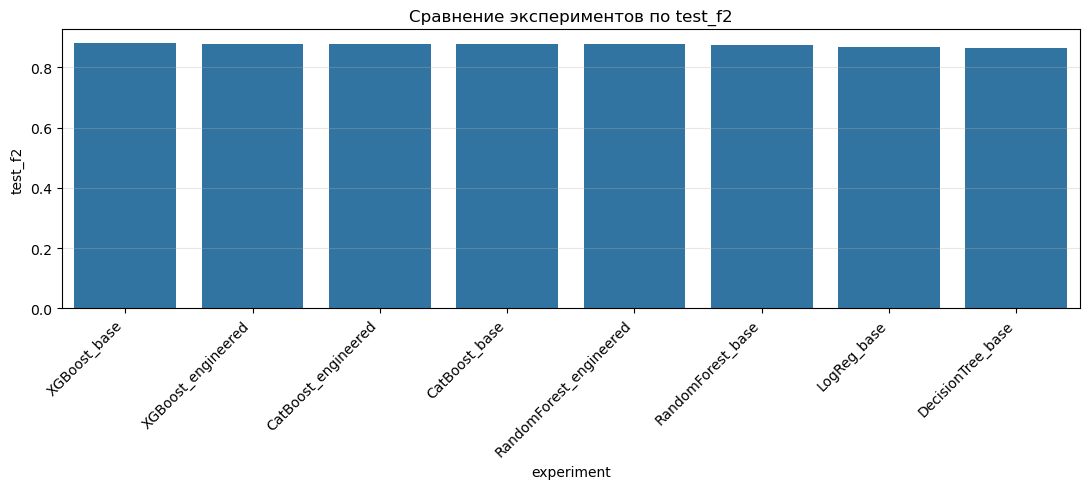

In [19]:
plt.figure(figsize=(11, 5))
sns.barplot(data=results_summary, x="experiment", y="test_f2")
plt.xticks(rotation=45, ha="right")
plt.title("Сравнение экспериментов по test_f2")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

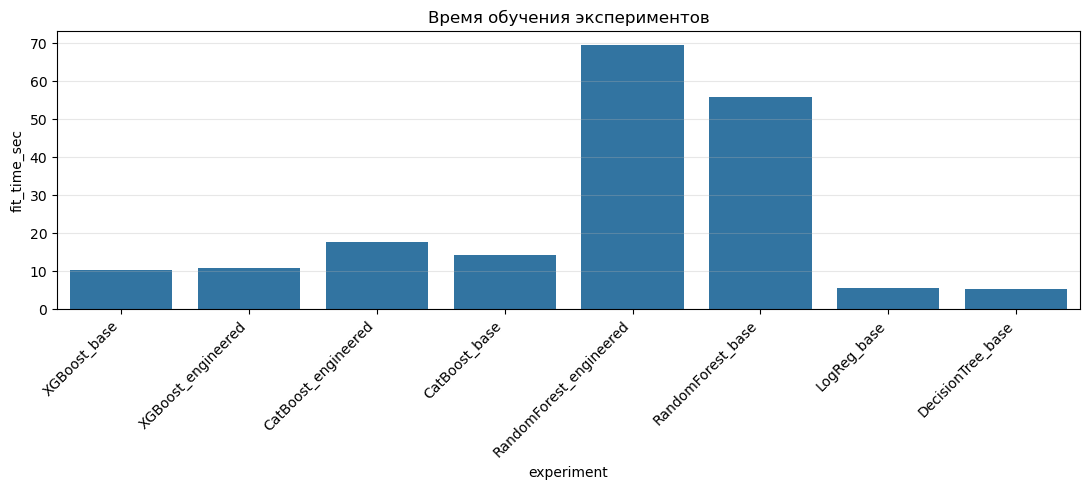

In [20]:
plt.figure(figsize=(11, 5))
sns.barplot(data=results_summary, x="experiment", y="fit_time_sec")
plt.xticks(rotation=45, ha="right")
plt.title("Время обучения экспериментов")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Помогает ли feature engineering

In [21]:
comparison = results_summary.pivot_table(
    index="model",
    columns="feature_set",
    values=["val_f2", "test_f2", "fit_time_sec"],
    aggfunc="first"
)
comparison

fit_time_sec            test_f2             val_f2           
feature_set                base engineered    base engineered    base engineered
model                                                                           
CatBoost                  14.16      17.58  0.8784     0.8789  0.8845     0.8853
DecisionTree               5.22        NaN  0.8638        NaN  0.8729        NaN
LogisticRegression         5.66        NaN  0.8688        NaN  0.8758        NaN
RandomForest              55.73      69.58  0.8740     0.8772  0.8861     0.8859
XGBoost                   10.19      10.92  0.8825     0.8793  0.8864     0.8840

## Важность признаков у лучшей модели

Лучшая модель:
experiment      XGBoost_base
model                XGBoost
feature_set             base
cv_f2                 0.8359
val_f2                0.8864
test_f2               0.8825
threshold               0.15
fit_time_sec           10.19
Name: 0, dtype: object


,feature,importance
0,age,0.116500
37,heart_axis_norm,0.095445
5,III_wavelet_E2,0.058785
13,V1_RMSSD,0.052364
4,III_PSD_std_freq,0.043397
15,V1_wavelet_entropy,0.041089
38,V1_pathological_Q,0.036064
1,I_prop_censored,0.035735
11,AVL_SNR_dB,0.031868
31,meanRR_global,0.027889


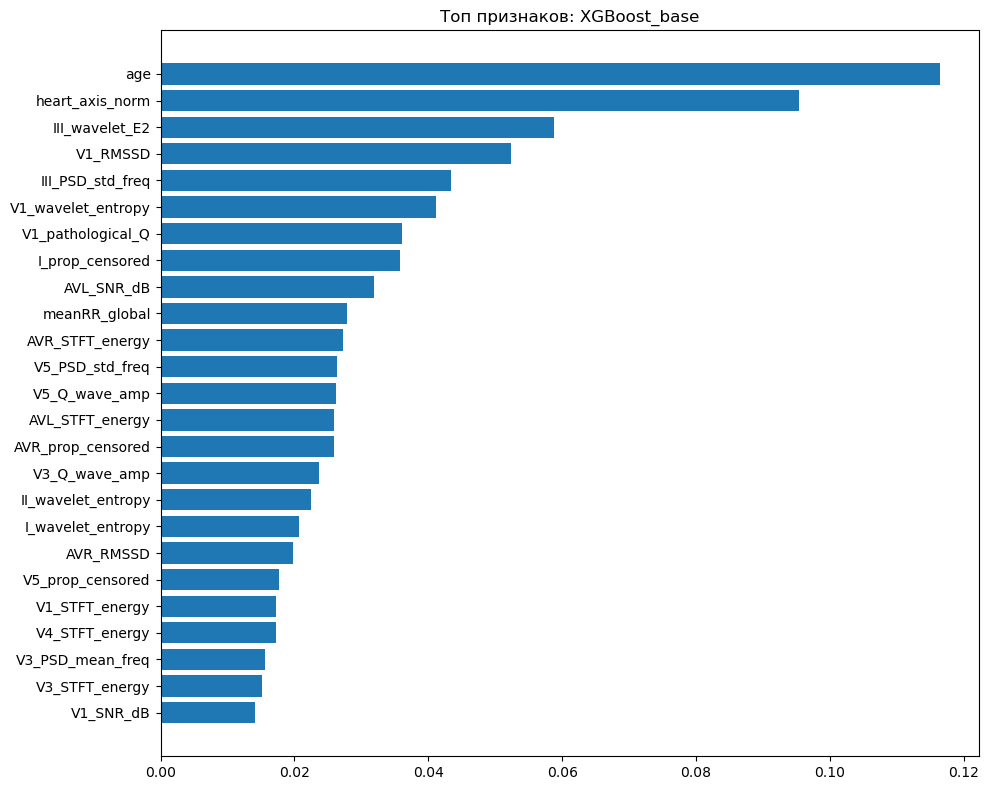

In [22]:
best_row = results_summary.iloc[0]
best_exp = best_row["experiment"]
best_bundle = fitted_models[best_exp]
best_model = best_bundle["raw_estimator"]
best_feature_names = best_bundle["feature_pack"]["feature_names"]

print("Лучшая модель:")
print(best_row[["experiment", "model", "feature_set", "cv_f2", "val_f2", "test_f2", "threshold", "fit_time_sec"]])

if hasattr(best_model, "feature_importances_"):
    imp = pd.DataFrame({
        "feature": best_feature_names,
        "importance": best_model.feature_importances_,
    }).sort_values("importance", ascending=False).head(25)

    display(imp)

    plt.figure(figsize=(10, 8))
    plt.barh(imp["feature"], imp["importance"])
    plt.gca().invert_yaxis()
    plt.title(f"Топ признаков: {best_exp}")
    plt.tight_layout()
    plt.show()

elif hasattr(best_model, "coef_"):
    coef = np.abs(best_model.coef_.ravel())
    imp = pd.DataFrame({
        "feature": best_feature_names,
        "importance": coef,
    }).sort_values("importance", ascending=False).head(25)

    display(imp)

    plt.figure(figsize=(10, 8))
    plt.barh(imp["feature"], imp["importance"])
    plt.gca().invert_yaxis()
    plt.title(f"Топ коэффициентов: {best_exp}")
    plt.tight_layout()
    plt.show()
else:
    print("У модели нет стандартного атрибута importance / coef_.")

## Метрики лучшей модели

In [23]:
best_row = results_summary.iloc[0]

print("Лучшее решение по test_f2:")
print(f"- experiment: {best_row['experiment']}")
print(f"- model: {best_row['model']}")
print(f"- feature_set: {best_row['feature_set']}")
print(f"- cv_f2: {best_row['cv_f2']}")
print(f"- val_f2: {best_row['val_f2']}")
print(f"- test_f2: {best_row['test_f2']}")
print(f"- val_recall: {best_row['val_recall']}")
print(f"- test_recall: {best_row['test_recall']}")
print(f"- threshold: {best_row['threshold']}")
print(f"- fit_time_sec: {best_row['fit_time_sec']}")
print(f"- best_params: {best_row['best_params']}")

Лучшее решение по test_f2:
- experiment: XGBoost_base
- model: XGBoost
- feature_set: base
- cv_f2: 0.8359
- val_f2: 0.8864
- test_f2: 0.8825
- val_recall: 0.9873
- test_recall: 0.9843
- threshold: 0.15
- fit_time_sec: 10.19
- best_params: {"colsample_bytree": 0.8, "learning_rate": 0.07, "max_depth": 3, "min_child_weight": 5, "n_estimators": 200, "reg_lambda": 1, "scale_pos_weight": 1.25, "subsample": 0.8}


Лучшая модель: XGBoost

Она выдает recall 0.984 на тестовых данных. В нашей задаче необходимо снизить до минимума кол-во ложноположительных ошибок